In [135]:
#imports
import sys
import os

# Adds the parent directory to the search path
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import xtrack as xt
import xpart as xp
import xobjects as xo


In [160]:
#read in file
df = pd.read_csv('PositronBeam_2p86GeV/Beam_3GHzOption_2.86GeV_20260421.dat', sep=r'\s+')
print(list(df.columns))


['x[mm]', 'xp[mrad]', 'y[mm]', 'yp[mrad]', 't[mm/c]', 'p[MeV/c]', 'ID']


141.12779013968762 MeV


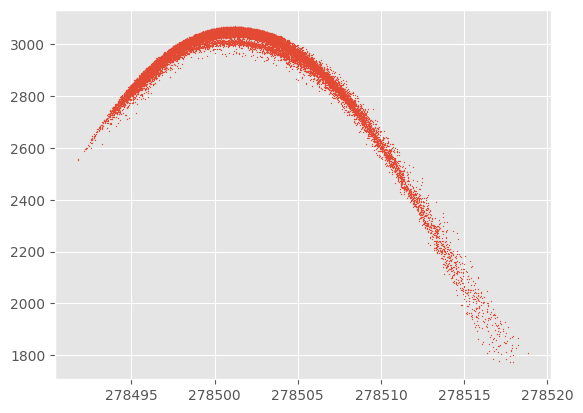

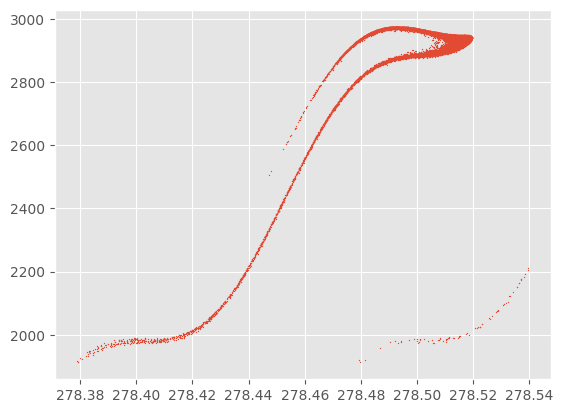

In [164]:
df_copy = df.copy()


Eref = np.mean(df['p[MeV/c]'])
R56= 0.352963
Vdeb= -0.048365
Phasdeb= 0.29229

V_int=abs(Vdeb)*Eref
print(f'{V_int} MeV')

# Relative momentum deviation
delta_i = df_copy['p[MeV/c]']/Eref - 1

# Convert z to meters
z_i = df_copy['t[mm/c]']*1e-3

# Compressor
z_f = z_i + R56*delta_i

# RF wave number
c = 299792458
freq = 3e9
k = 2*np.pi*freq/c

# RF kick
delta_f = delta_i + Vdeb*np.sin(k*z_f + Phasdeb)

# Final momentum
p_f = Eref*(1+delta_f)

# Store
df_copy['t[mm/c]'] = z_f
df_copy['delta_final'] = delta_f
df_copy['p[MeV/c]'] = p_f

main_bunch = df[df['t[mm/c]'] < 278540]
main_bunch_copy = df_copy[df_copy['t[mm/c]'] < 278.540]

plt.scatter(main_bunch['t[mm/c]'], main_bunch['p[MeV/c]'], s=0.2)
plt.show()

plt.scatter(main_bunch_copy['t[mm/c]'], main_bunch_copy['p[MeV/c]'], s=0.2)

plt.show()



In [165]:
df=df_copy
def CalcEmittanceManual(df, position, angle):
    pos = df[position].values
    ang = df[angle].values

    x_c = pos - np.mean(pos)
    xp_c = ang - np.mean(ang)

    x2_mean = np.mean(x_c**2)
    xp2_mean = np.mean(xp_c**2)
    xxp_mean = np.mean(x_c * xp_c)
    
    emittance = np.sqrt(x2_mean * xp2_mean - xxp_mean**2)
    return emittance

def CalcEmittanceAuto(df, position, angle):
    pos = df[position].values
    ang = df[angle].values
    
    cov = np.cov(pos, ang, ddof=0) 
    emittance = np.sqrt(np.linalg.det(cov))
    return emittance


def NormalisedEmittance(emittance, E_total_mev):
    # Electron/Positron rest mass in MeV
    m0 = 0.510998 
    
    gamma_rel = E_total_mev / m0
    beta_rel = np.sqrt(1 - 1/gamma_rel**2)
    
    n_emittance = beta_rel * gamma_rel * emittance
    return n_emittance

def get_twiss(df, position, angle, p_col='p[MeV/c]', p0_mev=2860.0):
    pos = df[position].values
    ang = df[angle].values
    
    # Calculate emittance 
    eps = CalcEmittanceAuto(df, position, angle)
    
    cov_matrix = np.cov(pos, ang, ddof=0)
    
    beta = cov_matrix[0, 0] / eps
    alpha = -cov_matrix[0, 1] / eps
    gamma = (1 + alpha**2) / beta
    
    # Dispersion calculation
    delta = (df[p_col].values - p0_mev) / p0_mev
    dispersion_x = np.cov(pos, delta, ddof=0)[0, 1] / np.var(delta)
    disp_prime_x = np.cov(ang, delta, ddof=0)[0, 1] / np.var(delta)
    
    return alpha, beta, gamma, dispersion_x, disp_prime_x



def plot_twiss_ellipse(beta, alpha, beta2, alpha2, emittance,ax):
    gamma = (1 + alpha**2) / beta
    theta = np.linspace(0, 2*np.pi, 100)
    
    x1 = np.sqrt(emittance * beta) * np.cos(theta)
    xp1 = -np.sqrt(emittance / beta) * (alpha * np.cos(theta) - np.sin(theta))
    x2 = np.sqrt(emittance * beta2) * np.cos(theta)
    xp2 = -np.sqrt(emittance / beta2) * (alpha2 * np.cos(theta) - np.sin(theta))
    
    #ax.figure(figsize=(6,6))
    ax.plot(x1, xp1, label=f'Particle distribution',color='blue')#: α={alpha:.2f}, β={beta:.2f} m',color='blue')
    ax.plot(x2, xp2, label=f'Initial ring parameters',color='red')#: α={alpha2:.2f}, β={beta2:.2f} m',color='red')
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.axvline(0, color='black', lw=0.5, ls='--')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    ax.axis('equal')

def normalisation_matrix(beta_r,alpha,beta_l,phi,x,xp):
    mat_A=np.array([
        [np.sqrt(beta_r),0],
        [-alpha/np.sqrt(beta_l),1/np.sqrt(beta_r)]
        ])

    mat_B=np.array([
        [np.cos(phi),np.sin(phi)],
        [-np.sin(phi),np.cos(phi)]
    ])

    mat_C=np.array([
        [1/np.sqrt(beta_l),0],
        [alpha/np.sqrt(beta_l),np.sqrt(beta_l)]
    ])

    x_col=np.array([
        [x],[xp]
    ])

    result=mat_A @ mat_B @ mat_C @ x_col

    zeta=result[0,0]
    zeta_prime=result[1,0]
    
    return zeta, zeta_prime

def plot_twiss_ellipse_normalised(beta_l,alpha_l,beta_r, alpha_r,disp,ddisp,delta,emittance,ax):

    phi=np.linspace(0,2*np.pi,500)

    x = np.sqrt(emittance * beta_l) * np.cos(phi)
    xp = - (np.sqrt(emittance / beta_l)) * (alpha_l * np.cos(phi) + np.sin(phi))


    zeta=(1/(np.sqrt(beta_l)))*x
    zeta_prime=np.sqrt(beta_l)*xp+(alpha_l/np.sqrt(beta_l))*x

    zeta_r=(1/(np.sqrt(beta_r)))*x
    zeta_prime_r=np.sqrt(beta_r)*xp+(alpha_r/np.sqrt(beta_r))*x

    x_b=x+disp*delta
    xp_b=xp+ddisp*delta

    print(disp*delta)


    zeta_r_d=(1/(np.sqrt(beta_r)))*x_b
    zeta_prime_r_d=np.sqrt(beta_r)*xp_b+(alpha_r/np.sqrt(beta_r))*x_b

    ax.plot(zeta, zeta_prime, color='blue', label='Particle distribution')
    ax.plot(zeta_r, zeta_prime_r, color='red', label='Initial ring parameters')
    ax.axis('equal') 
    ax.grid(True, linestyle=':')
    ax.legend()



def plot_twiss_with_particles(df, pos_col, ang_col, alpha, beta, emittance):
    gamma = (1 + alpha**2) / beta
    
    plt.figure(figsize=(7, 7))
    ax = plt.gca()
    
    ax.scatter(df[pos_col], df[ang_col], s=1, alpha=0.3, label='Particles')
    
    theta = np.linspace(0, 2*np.pi, 200)
    x = np.sqrt(emittance * beta) * np.cos(theta)
    xp = -np.sqrt(emittance / beta) * (alpha * np.cos(theta) - np.sin(theta))
    
    ax.plot(x, xp, color='red', lw=2, label=f'RMS Ellipse (ε={emittance:.2f})')
    
    
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_xlabel(pos_col)
    ax.set_ylabel(ang_col)
    ax.set_title(f'Phase Space: {pos_col} vs {ang_col}')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)
    
    plt.show()


In [166]:

emittance_x=CalcEmittanceAuto(df, 'x[mm]', 'xp[mrad]')
m_emittance_x=CalcEmittanceManual(df, 'x[mm]', 'xp[mrad]')
#nemitt_x=NormalisedEmittance(df['x[mm]'],df['xp[mrad]'],emittance_x)
#print(nemitt_x)
print(f'Horizontal geometric emittance:{emittance_x} um, {m_emittance_x}um' )

emittance_y=CalcEmittanceAuto(df, 'y[mm]', 'yp[mrad]')
m_emittance_y=CalcEmittanceManual(df, 'y[mm]', 'yp[mrad]')
print(f'Vertical geometric emittance:{emittance_y} um, {m_emittance_y}um' )
#nemitt_y=NormalisedEmittance(df['x[mm]'],df['xp[mrad]'],emittance_y)
#print(nemitt_y)

# Correct way to call it:
ax, bx, gx, dx, ddx = get_twiss(df, 'x[mm]', 'xp[mrad]')
# Correct way to call it:
ay, by, gy, dy, ddy = get_twiss(df, 'y[mm]', 'yp[mrad]')
print(f"Beam Twiss: alpha_x={ax:.3f}, beta_x={bx:.3f} m, dx={dx:.3f} m,ddx={ddx:.3f} m")
print(f"Beam Twiss: alpha_y={ay:.3f}, beta_y={by:.3f} m, dy={dx:.3f} m,ddy={ddx:.3f} m")

p_array=df['p[MeV/c]']

p_avg = np.mean(p_array)
rms_spread = np.std(p_array)  
relative_spread = (rms_spread / p_avg) *100

print(f"RMS Momentum Spread: {relative_spread} %")


Horizontal geometric emittance:1.3541771163694611 um, 1.3541771163694545um
Vertical geometric emittance:1.4207550898273413 um, 1.4207550898273411um
Beam Twiss: alpha_x=-2.176, beta_x=6.694 m, dx=0.306 m,ddx=0.086 m
Beam Twiss: alpha_y=0.644, beta_y=1.648 m, dy=0.306 m,ddy=0.086 m
RMS Momentum Spread: 5.8174432624557575 %


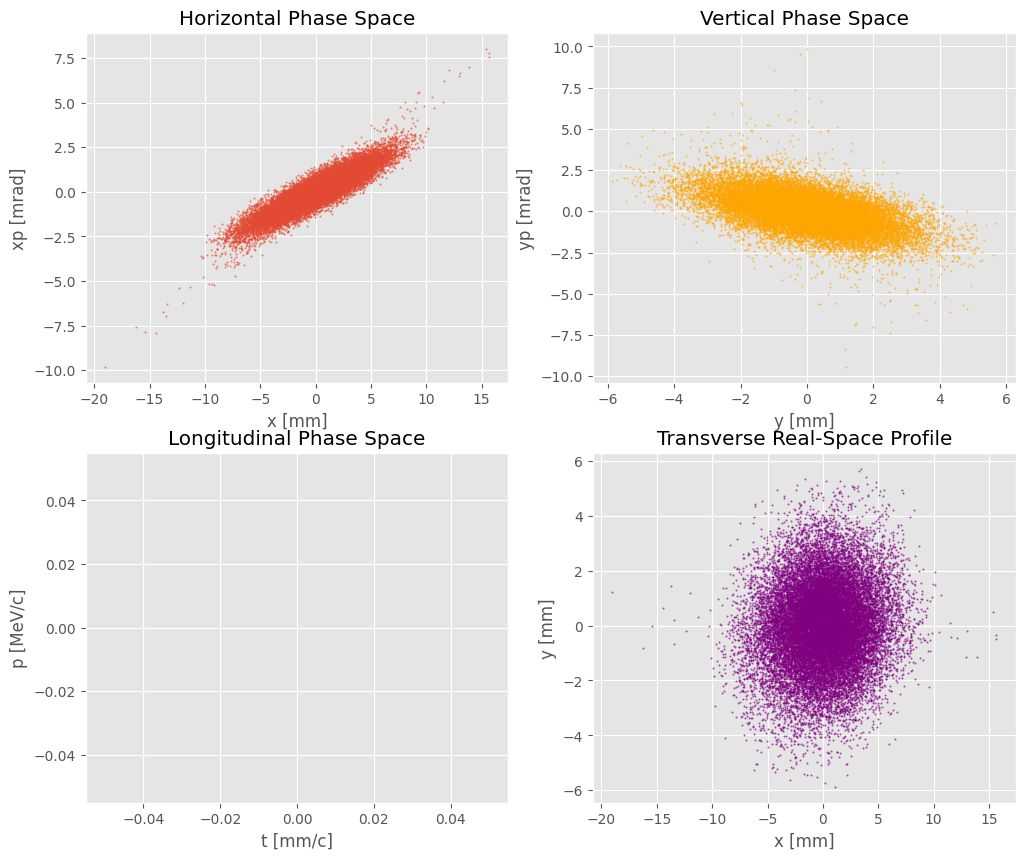

In [149]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Horizontal Phase Space
axes[0, 0].scatter(df['x[mm]'], df['xp[mrad]'], s=1, alpha=0.5)
axes[0, 0].set_xlabel('x [mm]')
axes[0, 0].set_ylabel('xp [mrad]')
axes[0, 0].set_title('Horizontal Phase Space')

#Vertical Phase Space
axes[0, 1].scatter(df['y[mm]'], df['yp[mrad]'], s=1, alpha=0.5, color='orange')
axes[0, 1].set_xlabel('y [mm]')
axes[0, 1].set_ylabel('yp [mrad]')
axes[0, 1].set_title('Vertical Phase Space')

#Longitudinal Phase Space
main_bunch = df[df['t[mm/c]'] < 278.540]
axes[1, 0].scatter(main_bunch['t[mm/c]'], main_bunch['p[MeV/c]'], s=1, alpha=0.5, color='green')
axes[1, 0].set_xlabel('t [mm/c]')
axes[1, 0].set_ylabel('p [MeV/c]')
axes[1, 0].set_title('Longitudinal Phase Space')

#Transverse Profile
axes[1, 1].scatter(df['x[mm]'], df['y[mm]'], s=1, alpha=0.5, color='purple')
axes[1, 1].set_xlabel('x [mm]')
axes[1, 1].set_ylabel('y [mm]')
axes[1, 1].set_title('Transverse Real-Space Profile')

plt.savefig('phase_space_plots.png')

/var/folders/gq/lbmdkcnd6gl8bmr8gkyg9pz80000gn/T/ipykernel_12386/4068080210.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


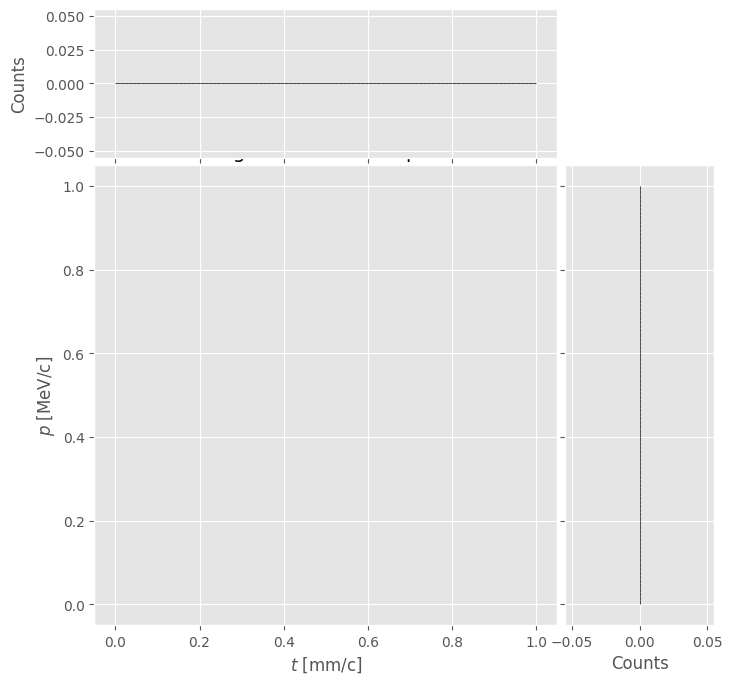

In [150]:
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt

# Apply mask consistently
mask = df['t[mm/c]'] < 278.540

t = df.loc[mask, 't[mm/c]']
p = df.loc[mask, 'p[MeV/c]']

# Style
plt.style.use('ggplot')

# Figure layout
fig = plt.figure(figsize=(8,8))
gs = GridSpec(
    4, 4,
    hspace=0.05,
    wspace=0.05
)

# Axes
ax_main  = fig.add_subplot(gs[1:4, 0:3])
ax_top   = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
ax_right = fig.add_subplot(gs[1:4, 3], sharey=ax_main)

# =========================
# Main longitudinal phase space
# =========================
ax_main.scatter(
    t,
    p,
    s=4,
    alpha=0.5,
    color='green'
)

ax_main.set_xlabel(r'$t$ [mm/c]')
ax_main.set_ylabel(r'$p$ [MeV/c]')
ax_main.set_title('Longitudinal Phase Space')

# =========================
# Top histogram
# =========================
ax_top.hist(
    t,
    bins=100,
    color='steelblue',
    edgecolor='black'
)

ax_top.set_ylabel('Counts')
ax_top.tick_params(axis='x', labelbottom=False)

# =========================
# Right histogram
# =========================
ax_right.hist(
    p,
    bins=100,
    orientation='horizontal',
    color='darkorange',
    edgecolor='black'
)

ax_right.set_xlabel('Counts')
ax_right.tick_params(axis='y', labelleft=False)

plt.tight_layout()
plt.show()

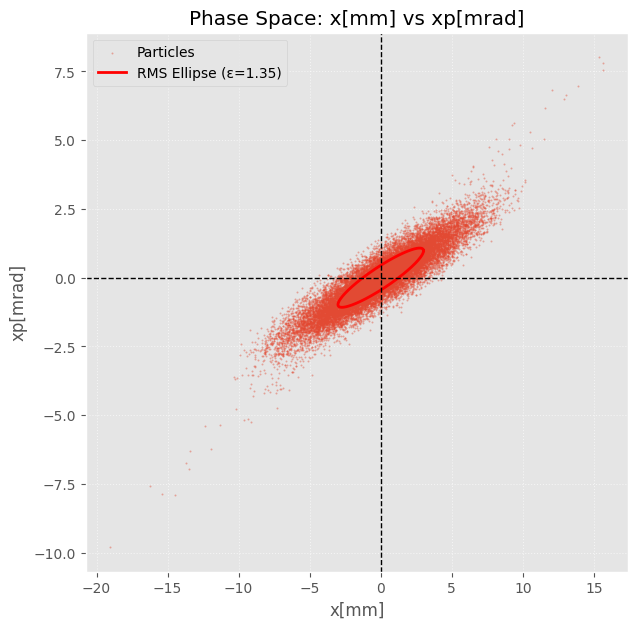

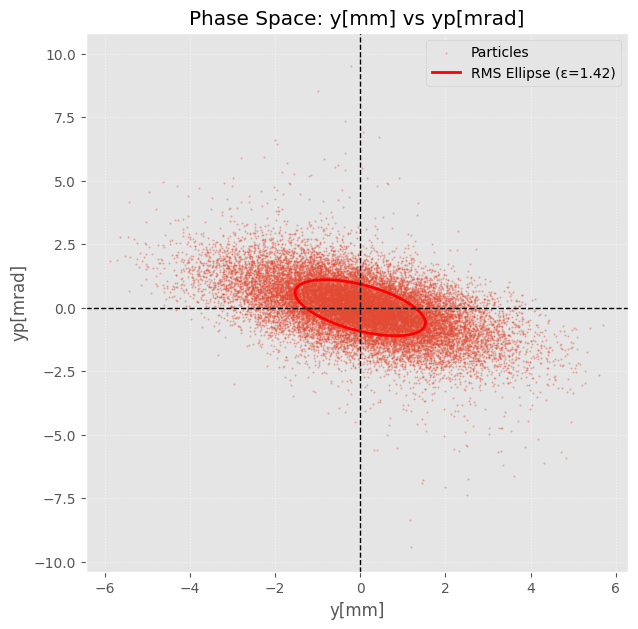

In [151]:

plot_twiss_with_particles(df, 'x[mm]', 'xp[mrad]', ax, bx, emittance_x)
plot_twiss_with_particles(df, 'y[mm]', 'yp[mrad]', ay, by, emittance_y)

In [152]:

# Save twiss results
beam_results = {
    "x": {
        "alpha": float(ax),
        "beta": float(bx),
        "gamma": float(gx),
        "dispersion": float(dx),
        "dispersion_prime": float(ddx),
        "emittance_geo": float(emittance_x)
    },
    "y": {
        "alpha": float(ay),
        "beta": float(by),
        "gamma": float(gy),
        "dispersion": float(dy),
        "dispersion_prime": float(ddy),
        "emittance_geo": float(emittance_y)
    },
    "metadata": {
        "particle_type": "positron",
        "design_energy_mev": 2860.0,
        "n_particles": len(df['ID'])
    }
}

with open('TwissResults.json', 'w') as f:
    json.dump(beam_results, f, indent=4)


Loading line from dict:   0%|          | 0/4079 [00:00<?, ?it/s]

Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           
ColView: name s x px y py zeta delta ptau W_matrix kin_px kin_py kin_ps kin_xprime kin_yprime env_name betx bety alfx alfy gamx gamy dx dpx dy dpy dx_zeta dpx_zeta dy_zeta dpy_zeta betx1 bety1 betx2 bety2 alfx1 alfy1 alfx2 alfy2 gamx1 gamy1 gamx2 gamy2 mux muy muzeta nux nuy nuzeta phix phiy phizeta c_minus_re c_minus_im c_r1 c_r2 c_phi1 c_phi2 dmux dmuy dzeta bx_chrom by_chrom ax_chrom ay_chrom wx_chrom wy_chrom ddx ddpx ddy ddpy
-2.8680229439299306e-05
0.0
-2.8680229439299306e-05
0.0


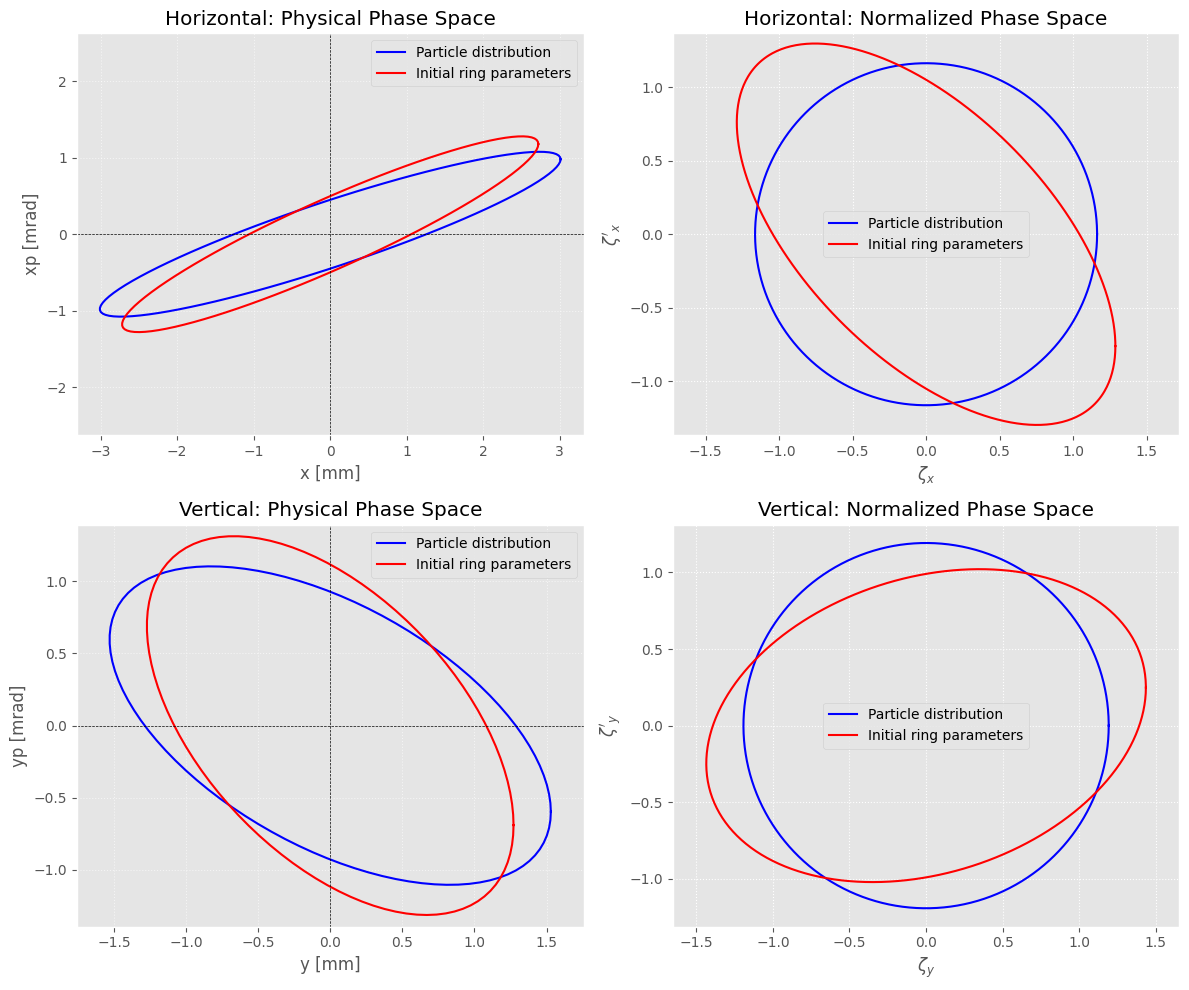

In [153]:
ring=xt.Line.from_json('design_1.json')

#ring twiss values
ring_tw=ring.twiss6d()
print(ring_tw.cols)
# Initial values
initial_twiss = ring_tw.rows[0]

#Horizontal
betx0 = initial_twiss['betx'][0]
alfx0 = initial_twiss['alfx'][0]
dx0   = initial_twiss['dx'][0]
ddx0   = initial_twiss['ddx'][0]
x     = initial_twiss['x'][0]
xp_v    = initial_twiss['px'][0]


#Vertical
bety0 = initial_twiss['bety'][0]
alfy0 = initial_twiss['alfy'][0]
dy0   = initial_twiss['dy'][0]
ddy0   = initial_twiss['ddy'][0]
y     = initial_twiss['y'][0]
yp    = initial_twiss['py'][0]

delta= initial_twiss['delta'][0]

plot_twiss_ellipse(bx,ax,betx0, alfx0, emittance_x,axes[0, 0])
plot_twiss_ellipse(by,ay,bety0, alfy0, emittance_y,axes[1, 0])

plot_twiss_ellipse_normalised(bx*1e-3,ax,betx0, alfx0,dx0,ddx0,delta, emittance_x,axes[0,1])
plot_twiss_ellipse_normalised(by*1e-3,ay,bety0, alfy0,dy0,ddy0,delta, emittance_y,axes[1, 1])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_twiss_ellipse(bx,ax,betx0, alfx0, emittance_x,axes[0, 0])
plot_twiss_ellipse(by,ay,bety0, alfy0, emittance_y,axes[1, 0])

plot_twiss_ellipse_normalised(bx,ax,betx0, alfx0,dx0,ddx0,delta, emittance_x,axes[0,1])
plot_twiss_ellipse_normalised(by,ay,bety0, alfy0,dy0,ddy0,delta, emittance_y,axes[1, 1])

axes[0, 0].set_title("Horizontal: Physical Phase Space")
axes[0, 0].set_xlabel("x [mm]")
axes[0, 0].set_ylabel("xp [mrad]")

axes[0, 1].set_title("Horizontal: Normalized Phase Space")
axes[0, 1].set_xlabel(r"$\zeta_x$")
axes[0, 1].set_ylabel(r"$\zeta'_x$")


axes[1, 0].set_title("Vertical: Physical Phase Space")
axes[1, 0].set_xlabel("y [mm]")
axes[1, 0].set_ylabel("yp [mrad]")

axes[1, 1].set_title("Vertical: Normalized Phase Space")
axes[1, 1].set_xlabel(r"$\zeta_y$")
axes[1, 1].set_ylabel(r"$\zeta'_y$")
plt.xlabel
plt.tight_layout()
plt.savefig('twiss_ellipses.png')
plt.show()


In [154]:
#Particle mapping

#Reference particle
p0c_reference = df['p[MeV/c]'].mean() * 1e6 
#p0c_reference = 2952.525*1e6

ref_particle = xp.Particles(p0c=p0c_reference, mass0=xp.ELECTRON_MASS_EV)

rand_num=74
n_subset = 500
df_subset = df.sample(n=n_subset, random_state=rand_num)

#Map coordinates
x = df_subset['x[mm]'].values * 1e-3
y = df_subset['y[mm]'].values * 1e-3
px = df_subset['xp[mrad]'].values * 1e-3
py = df_subset['yp[mrad]'].values * 1e-3

delta = (df_subset['p[MeV/c]'].values * 1e6 - p0c_reference) / p0c_reference

x_matched = (df_subset['x[mm]'].values * 1e-3) + (dx * delta) 
px_matched = (df_subset['xp[mrad]'].values * 1e-3) + (ddx * delta) 

y_matched = (df_subset['y[mm]'].values * 1e-3) + (dy * delta) 
py_matched = (df_subset['yp[mrad]'].values * 1e-3) + (ddy * delta) 

t_mm = df_subset['t[mm/c]'].values
zeta = (np.mean(t_mm) - t_mm) * 1e-3 * ref_particle.beta0[0]

particles = xp.Particles(
    p0c=p0c_reference,
    mass0=xp.ELECTRON_MASS_EV,
    x=x_matched,
    px=px_matched,
    y=y_matched,
    py=py_matched,
    zeta=zeta,
    delta=delta
)


Tracking:   0%|          | 0/6100 [00:00<?, ?it/s]

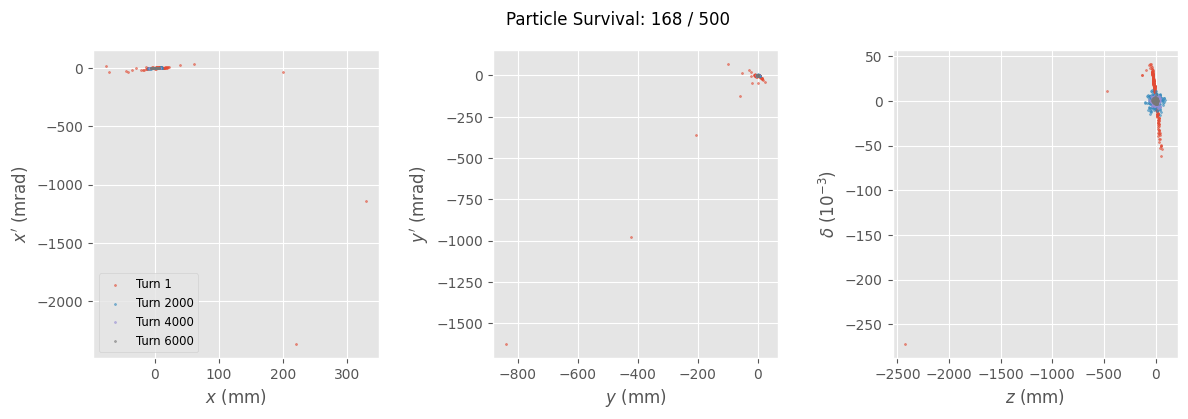

In [155]:
n_track = len(particles.x) 
ring.configure_radiation(model='quantum')
ring.track(particles, num_turns=6100,turn_by_turn_monitor=True, with_progress=True)


data = ring.record_last_track
trnplt = [1, 2000, 4000, 6000]


fig, ax = plt.subplots(1, 3, figsize=(14, 4))
fig.subplots_adjust(wspace=0.4)

survival_count = np.sum(particles.state > 0)
fig.suptitle(f'Particle Survival: {survival_count} / {n_track}')


labels = [("$x$ (mm)", "$x'$ (mrad)"), 
          ("$y$ (mm)", "$y'$ (mrad)"), 
          ("$z$ (mm)", "$\\delta$ ($10^{-3}$)" )]

for i, (xl, yl) in enumerate(labels):
    ax[i].set_xlabel(xl)
    ax[i].set_ylabel(yl)


for ind, turn in enumerate(trnplt):

    x_beta = 1000 * (data.x[:, turn] - ring_tw.dx[0] * data.delta[:, turn])
    px_beta = 1000 * (data.px[:, turn] - ring_tw.dpx[0] * data.delta[:, turn])
    ax[0].scatter(x_beta, px_beta, s=2, color=f'C{ind}', label=f'Turn {turn}', alpha=0.6)
    
    # Vertical
    ax[1].scatter(1000 * data.y[:, turn], 1000 * data.py[:, turn], s=2, color=f'C{ind}', alpha=0.6)
    
    # Longitudinal
    ax[2].scatter(1000 * data.zeta[:, turn], 1000 * data.delta[:, turn], s=2, color=f'C{ind}', alpha=0.6)

ax[0].legend(fontsize='small')


plt.savefig(f'injection_tracking_evolution_{rand_num}_{p0c_reference/1e6}MeV.png')

<>:10: SyntaxWarning: invalid escape sequence '\z'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\z'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/var/folders/gq/lbmdkcnd6gl8bmr8gkyg9pz80000gn/T/ipykernel_12386/318421663.py:10: SyntaxWarning: invalid escape sequence '\z'
  ("$\zeta$ (mm)", "$\delta$ ($10^{-3}$)"),
/var/folders/gq/lbmdkcnd6gl8bmr8gkyg9pz80000gn/T/ipykernel_12386/318421663.py:10: SyntaxWarning: invalid escape sequence '\d'
  ("$\zeta$ (mm)", "$\delta$ ($10^{-3}$)"),


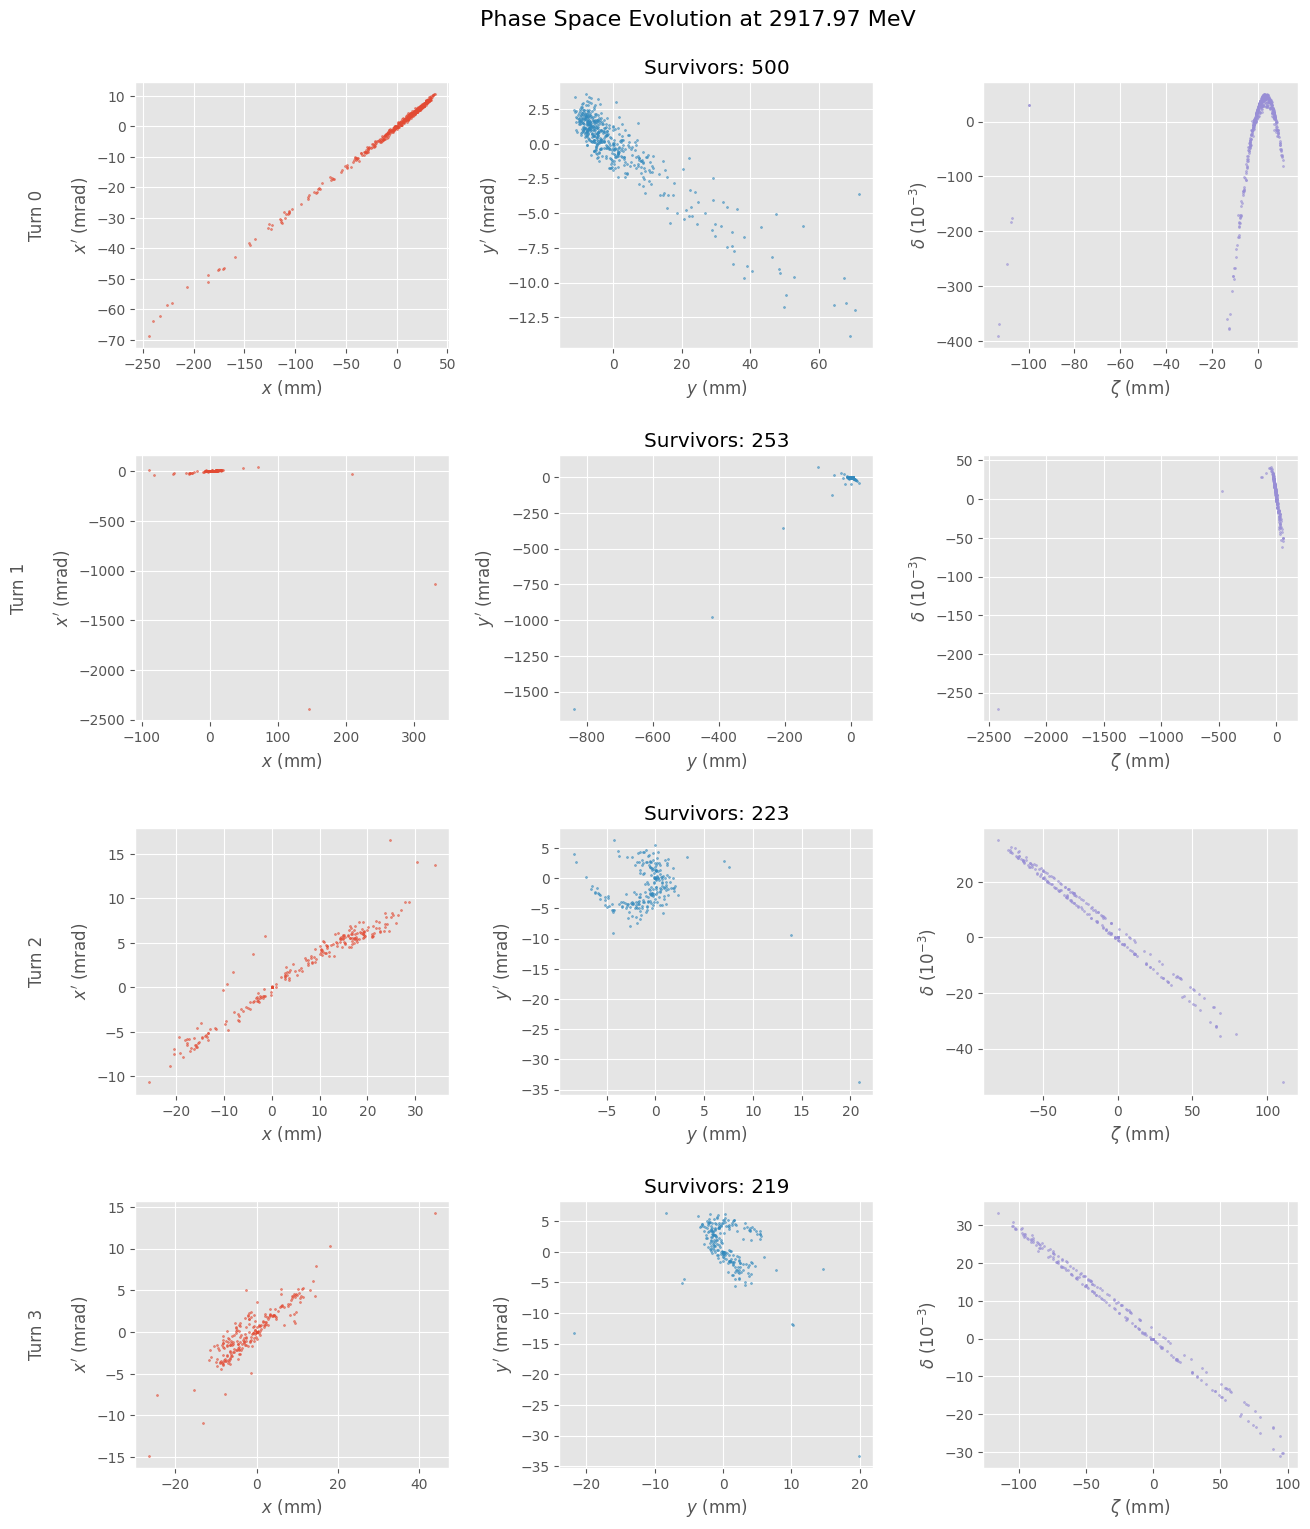

In [156]:


turns_to_plot = [0, 1, 2, 3]


fig, axes = plt.subplots(4, 3, figsize=(15, 18))
fig.subplots_adjust(hspace=0.4, wspace=0.35)

col_labels = [
    ("$x$ (mm)", "$x'$ (mrad)"),
    ("$y$ (mm)", "$y'$ (mrad)"),
    ("$\zeta$ (mm)", "$\delta$ ($10^{-3}$)"),
    ("$x$ (mm)", "$y$ (mm)")
]

for row, turn in enumerate(turns_to_plot):
    survived = np.sum(data.state[:, turn] > 0)
    
    axes[row, 0].scatter(data.x[:, turn]*1000, data.px[:, turn]*1000, s=2, color='C0', alpha=0.6)
    axes[row, 0].set_xlabel(col_labels[0][0])
    axes[row, 0].set_ylabel(f"Turn {turn}\n\n{col_labels[0][1]}")
    
    axes[row, 1].scatter(data.y[:, turn]*1000, data.py[:, turn]*1000, s=2, color='C1', alpha=0.6)
    axes[row, 1].set_xlabel(col_labels[1][0])
    axes[row, 1].set_ylabel(col_labels[1][1])
    axes[row, 1].set_title(f"Survivors: {survived}")
    
    axes[row, 2].scatter(data.zeta[:, turn]*1000, data.delta[:, turn]*1000, s=2, color='C2', alpha=0.6)
    axes[row, 2].set_xlabel(col_labels[2][0])
    axes[row, 2].set_ylabel(col_labels[2][1])
    

fig.suptitle(f'Phase Space Evolution at {p0c_reference/1e6:.2f} MeV', fontsize=16, y=0.92)
plt.savefig(f'initial_turns_{rand_num}_{int(p0c_reference/1e6)} MeV.png')
plt.show()

/var/folders/gq/lbmdkcnd6gl8bmr8gkyg9pz80000gn/T/ipykernel_12386/1258639555.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


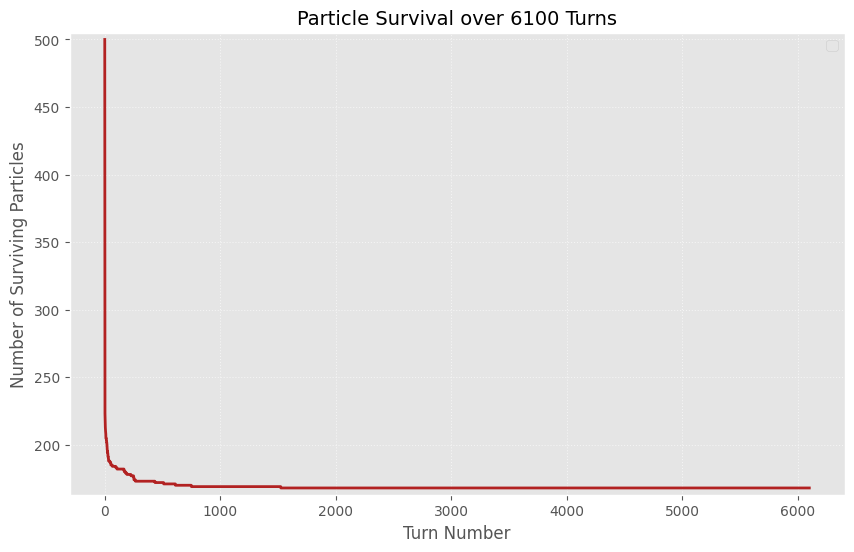

Final Survival: 168 / 500 (33.60%)


In [157]:
survival_counts = np.sum(data.state > 0, axis=0)
turns = np.arange(len(survival_counts))

# 2. Plotting
plt.figure(figsize=(10, 6))
plt.plot(turns, survival_counts, color='firebrick', linewidth=2)

plt.title(f'Particle Survival over {len(turns)} Turns', fontsize=14)
plt.xlabel('Turn Number', fontsize=12)
plt.ylabel('Number of Surviving Particles', fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.ylim(min(survival_counts)-5, survival_counts[0]+5)  # Set y-axis to start at 0
plt.legend()


# 3. Save the plot
plt.savefig(f'survival_vs_turns_{int(p0c_reference/1e6)}MeV.png', bbox_inches='tight')
plt.show()

# Print final efficiency
final_efficiency = (survival_counts[-1] / survival_counts[0]) * 100
print(f"Final Survival: {survival_counts[-1]} / {survival_counts[0]} ({final_efficiency:.2f}%)")

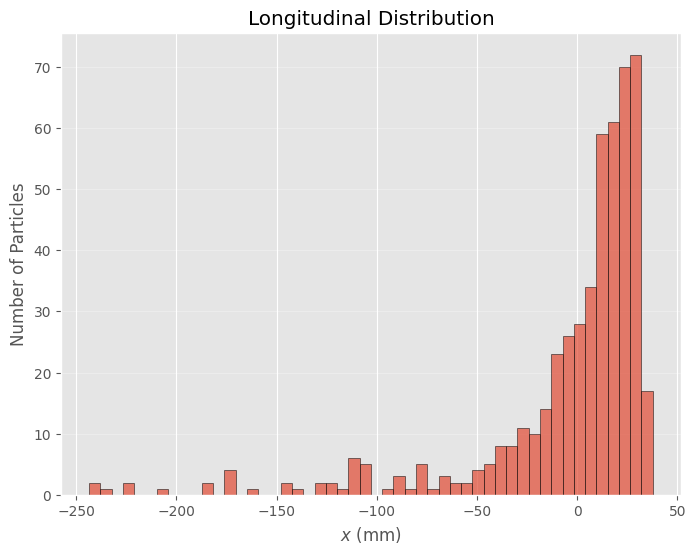

In [158]:
plt.figure(figsize=(8, 6))
plt.hist(data.x[:, 0] * 1000, bins=50, color='C0', edgecolor='black', alpha=0.7)
plt.xlabel('$x$ (mm)')
plt.ylabel('Number of Particles')
plt.title(f'Longitudinal Distribution')
plt.grid(axis='y', alpha=0.3)
plt.savefig(f'initial_x_distribution_{int(p0c_reference/1e6)}MeV.png')
plt.show()

Energy: 2500.000 MeV | Efficiency: 0.0%
Energy: 2507.071 MeV | Efficiency: 0.0%
Energy: 2514.141 MeV | Efficiency: 0.0%
Energy: 2521.212 MeV | Efficiency: 0.0%
Energy: 2528.283 MeV | Efficiency: 0.0%
Energy: 2535.354 MeV | Efficiency: 0.0%
Energy: 2542.424 MeV | Efficiency: 0.0%
Energy: 2549.495 MeV | Efficiency: 0.0%
Energy: 2556.566 MeV | Efficiency: 0.0%
Energy: 2563.636 MeV | Efficiency: 0.0%
Energy: 2570.707 MeV | Efficiency: 0.0%
Energy: 2577.778 MeV | Efficiency: 0.0%
Energy: 2584.848 MeV | Efficiency: 0.0%
Energy: 2591.919 MeV | Efficiency: 0.0%
Energy: 2598.990 MeV | Efficiency: 0.0%
Energy: 2606.061 MeV | Efficiency: 0.0%
Energy: 2613.131 MeV | Efficiency: 0.0%
Energy: 2620.202 MeV | Efficiency: 0.0%
Energy: 2627.273 MeV | Efficiency: 0.0%
Energy: 2634.343 MeV | Efficiency: 0.0%
Energy: 2641.414 MeV | Efficiency: 0.0%
Energy: 2648.485 MeV | Efficiency: 0.0%
Energy: 2655.556 MeV | Efficiency: 0.0%
Energy: 2662.626 MeV | Efficiency: 0.0%
Energy: 2669.697 MeV | Efficiency: 0.0%


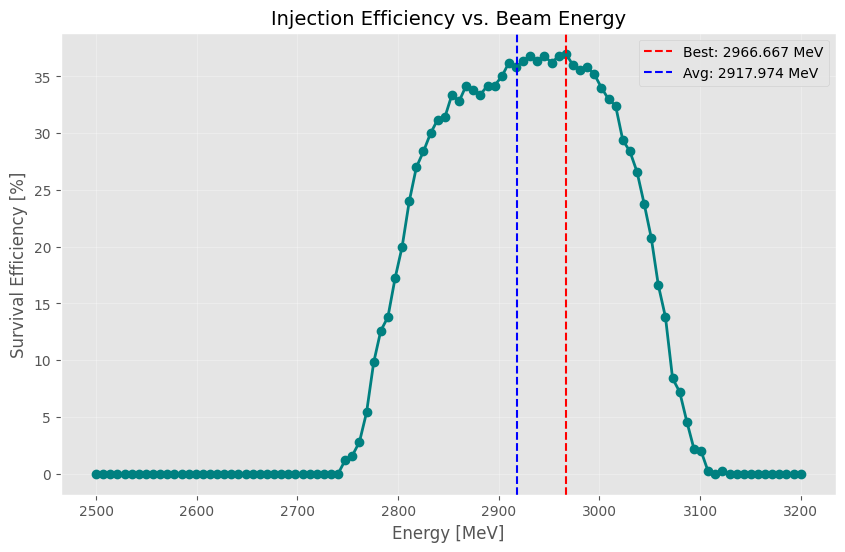


The best injection efficiency is at 2966.667 MeV.


In [159]:
energy_range_mev = np.linspace(2.5e3, 3.2e3, 100)  
efficiency_results = []


for e_mev in energy_range_mev:
    p0c_test = e_mev * 1e6 
   
    ring.particle_ref = xp.Particles(p0c=p0c_test, mass0=xp.ELECTRON_MASS_EV)
    
    delta_test = (df_subset['p[MeV/c]'].values - e_mev) / e_mev
    

    p_test = xp.Particles(
        p0c=p0c_test,
        mass0=xp.ELECTRON_MASS_EV,
        x=x_matched, px=px_matched,
        y=y_matched, py=py_matched,
        delta=delta_test,
        zeta=zeta
    )
    
   
    ring.track(p_test, num_turns=100)
    
    survived = np.sum(p_test.state > 0)
    efficiency = (survived / len(p_test.x)) * 100
    efficiency_results.append(efficiency)
    
    print(f"Energy: {e_mev:.3f} MeV | Efficiency: {efficiency:.1f}%")

best_idx = np.argmax(efficiency_results)
best_energy = energy_range_mev[best_idx]

p0c_reference = df['p[MeV/c]'].mean() * 1e6 

plt.figure(figsize=(10, 6))
plt.plot(energy_range_mev, efficiency_results, 'o-', color='teal', linewidth=2)
plt.axvline(best_energy, color='red', linestyle='--', label=f'Best: {best_energy:.3f} MeV')
plt.axvline(p0c_reference/1e6, color='blue', linestyle='--', label=f'Avg: {p0c_reference/1e6:.3f} MeV')

plt.title('Injection Efficiency vs. Beam Energy', fontsize=14)
plt.xlabel('Energy [MeV]', fontsize=12)
plt.ylabel('Survival Efficiency [%]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"\nThe best injection efficiency is at {best_energy:.3f} MeV.")

In [ ]:
rand_range = range(1, 51) 
efficiency_results = []
n_particles = 500 
#p0c_reference = df['p[MeV/c]'].mean() * 1e6 
fixed_e_mev = p0c_reference / 1e6
ring.particle_ref = xp.Particles(p0c=p0c_reference, mass0=xp.ELECTRON_MASS_EV)

print(f"Starting Random Number Scan at {fixed_e_mev:.2f} MeV...")

for r in rand_range:
    df_subset = df.sample(n=n_particles, random_state=r)
    
    # Re-map coordinates for the new subset
    x_in = df_subset['x[mm]'].values / 1000.0
    px_in = df_subset['xp[mrad]'].values / 1000.0
    y_in = df_subset['y[mm]'].values / 1000.0
    py_in = df_subset['yp[mrad]'].values / 1000.0
    zeta_in = df_subset['t[mm/c]'].values / 1000.0
    delta_in = (df_subset['p[MeV/c]'].values - fixed_e_mev) / fixed_e_mev

    # Apply matching (Assuming ring_tw is already defined)
    x_matched = x_in + ring_tw.dx[0] * delta_in
    px_matched = px_in + ring_tw.dpx[0] * delta_in
    y_matched = y_in + ring_tw.dy[0] * delta_in
    py_matched = py_in + ring_tw.dpy[0] * delta_in

    p_test = xp.Particles(
        p0c=p0c_reference,
        mass0=xp.ELECTRON_MASS_EV,
        x=x_matched, px=px_matched,
        y=y_matched, py=py_matched,
        delta=delta_in,
        zeta=zeta_in
    )

    ring.track(p_test, num_turns=100)
    
    survived = np.sum(p_test.state > 0)
    efficiency = (survived / n_particles) * 100
    efficiency_results.append(efficiency)
    
    print(f"Seed: {r} | Efficiency: {efficiency:.1f}%")

avg_eff = np.mean(efficiency_results)


Starting Random Number Scan at 2882.03 MeV...
Seed: 1 | Efficiency: 95.2%


KeyboardInterrupt: 

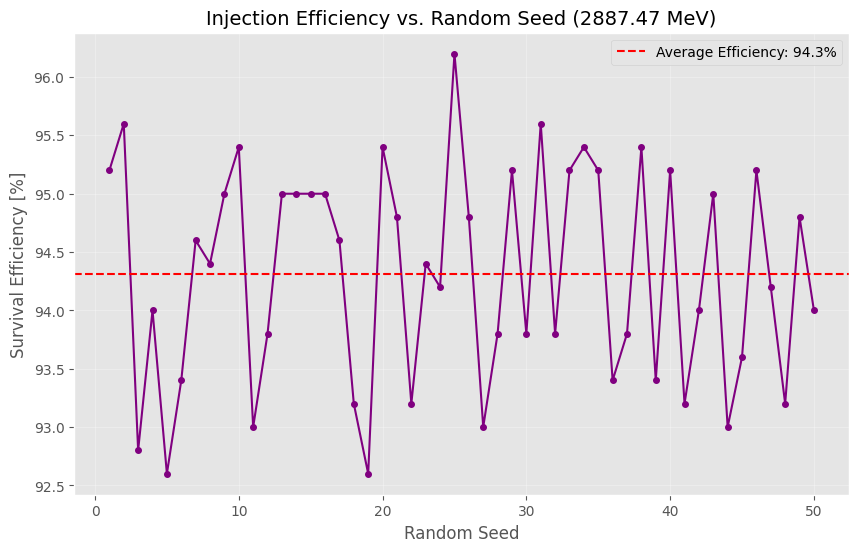


Scan Complete. Average efficiency across 50 samples: 94.31%


In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(rand_range, efficiency_results, 'o-', color='purple', linewidth=1.5, markersize=4)
plt.axhline(avg_eff, color='red', linestyle='--', label=f'Average Efficiency: {avg_eff:.1f}%')

plt.title(f'Injection Efficiency vs. Random Seed ({fixed_e_mev:.2f} MeV)', fontsize=14)
plt.xlabel('Random Seed', fontsize=12)
plt.ylabel('Survival Efficiency [%]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(f'efficiency_random_scan_{int(fixed_e_mev)}MeV.png')
plt.show()

print(f"\nScan Complete. Average efficiency across {len(rand_range)} samples: {avg_eff:.2f}%")

Scanning ECS parameters...

--- Optimization Complete ---
Best R56:        0.750000 m
Best Vdeb:       -0.710526
Best Phase:      0.450000 rad

Gaussian Mean:   1072.492782 MeV/c
Gaussian Sigma:  -226.267086 MeV/c
Relative Spread: -21.097306 %
FWHM:            -532.858988 MeV/c
Optimization Score: -528.622817


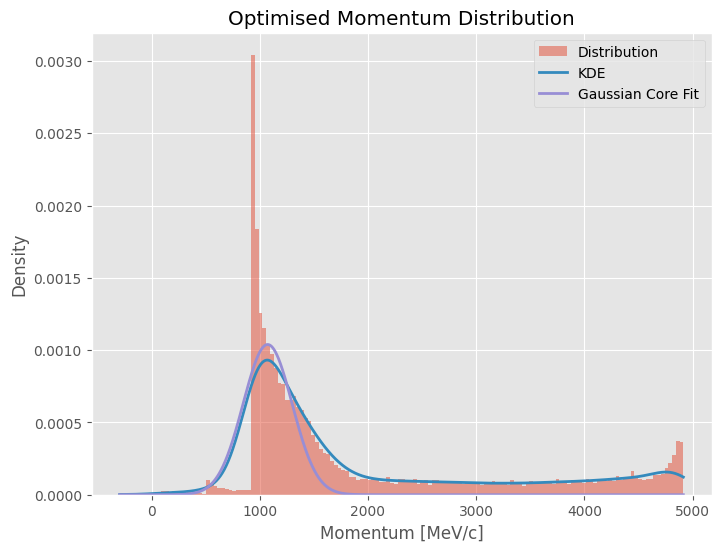

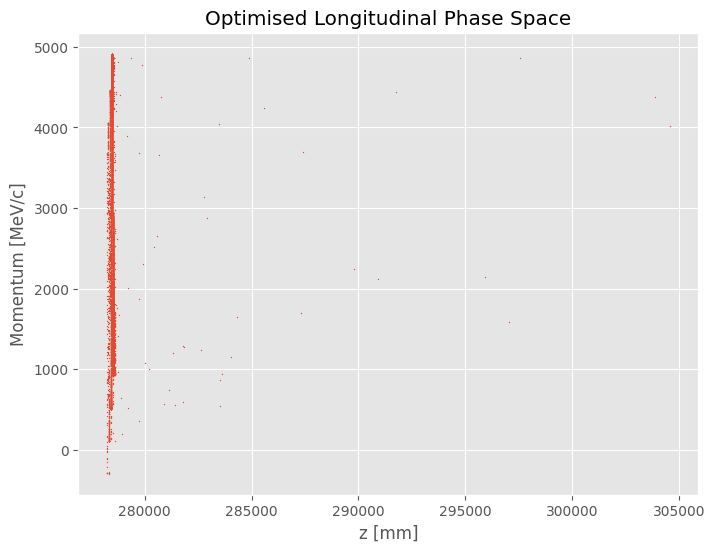

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde, skew, kurtosis

c = 299792458
freq = 3e9
k = 2 * np.pi * freq / c

z_i = df['t[mm/c]'].values * 1e-3
p_i = df['p[MeV/c]'].values

Eref = np.mean(p_i)

R56_scan = np.linspace(0.0, 0.75, 20)
Vdeb_scan = np.linspace(-0.75, 0.0, 20)
Phase_scan = np.linspace(0.0, 0.45, 20)

delta_i = p_i / Eref - 1

best_score = np.inf
best_sigma = np.inf
best_params = None
best_distribution = None
best_fit = None

def gaussian(x, A, mu, sigma):

    return A * np.exp(
        -(x - mu)**2 / (2 * sigma**2)
    )

print("Scanning ECS parameters...")

for R56 in R56_scan:

    z_f = z_i + R56 * delta_i

    for Vdeb in Vdeb_scan:

        for phase in Phase_scan:

            delta_f = (
                delta_i
                + Vdeb * np.sin(k * z_f + phase)
            )

            p_f = Eref * (1 + delta_f)

            core_percent = 90

            lower_p = np.percentile(
                p_f,
                (100 - core_percent) / 2
            )

            upper_p = np.percentile(
                p_f,
                100 - (100 - core_percent) / 2
            )

            core = p_f[
                (p_f >= lower_p)
                &
                (p_f <= upper_p)
            ]

            kde = gaussian_kde(core)

            x = np.linspace(
                np.min(core),
                np.max(core),
                2000
            )

            y = kde(x)

            peak_index = np.argmax(y)

            peak_x = x[peak_index]

            fit_width = 40

            fit_mask = (
                (x > peak_x - fit_width)
                &
                (x < peak_x + fit_width)
            )

            x_fit = x[fit_mask]
            y_fit = y[fit_mask]

            A0 = np.max(y_fit)
            mu0 = peak_x
            sigma0 = np.std(core)

            try:

                popt, _ = curve_fit(
                    gaussian,
                    x_fit,
                    y_fit,
                    p0=[A0, mu0, sigma0]
                )

                A_fit, mu_fit, sigma_fit = popt

            except:

                continue

            sk = abs(skew(core))
            ku = abs(kurtosis(core))

            score = sigma_fit * (
                1 + sk + 0.2 * ku
            )

            if score < best_score:

                best_score = score

                best_sigma = sigma_fit

                best_params = (
                    R56,
                    Vdeb,
                    phase
                )

                best_distribution = (
                    z_f.copy(),
                    p_f.copy()
                )

                best_fit = (
                    A_fit,
                    mu_fit,
                    sigma_fit
                )

print("\n--- Optimization Complete ---")

print(f"Best R56:        {best_params[0]:.6f} m")
print(f"Best Vdeb:       {best_params[1]:.6f}")
print(f"Best Phase:      {best_params[2]:.6f} rad")

print(f"\nGaussian Mean:   {best_fit[1]:.6f} MeV/c")
print(f"Gaussian Sigma:  {best_fit[2]:.6f} MeV/c")

print(
    f"Relative Spread: "
    f"{100 * best_fit[2] / best_fit[1]:.6f} %"
)

print(
    f"FWHM:            "
    f"{2.355 * best_fit[2]:.6f} MeV/c"
)

print(f"Optimization Score: {best_score:.6f}")

z_best, p_best = best_distribution

A_fit, mu_fit, sigma_fit = best_fit

kde = gaussian_kde(p_best)

x = np.linspace(
    np.min(p_best),
    np.max(p_best),
    2000
)

y = kde(x)

gauss_fit = gaussian(
    x,
    A_fit,
    mu_fit,
    sigma_fit
)

plt.figure(figsize=(8,6))

plt.hist(
    p_best,
    bins=150,
    density=True,
    alpha=0.5,
    label='Distribution'
)

plt.plot(
    x,
    y,
    linewidth=2,
    label='KDE'
)

plt.plot(
    x,
    gauss_fit,
    linewidth=2,
    label='Gaussian Core Fit'
)

plt.xlabel('Momentum [MeV/c]')
plt.ylabel('Density')

plt.title('Optimised Momentum Distribution')

plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,6))

plt.scatter(
    z_best * 1e3,
    p_best,
    s=0.2
)

plt.xlabel('z [mm]')
plt.ylabel('Momentum [MeV/c]')

plt.title('Optimised Longitudinal Phase Space')

plt.grid(True)

plt.show()

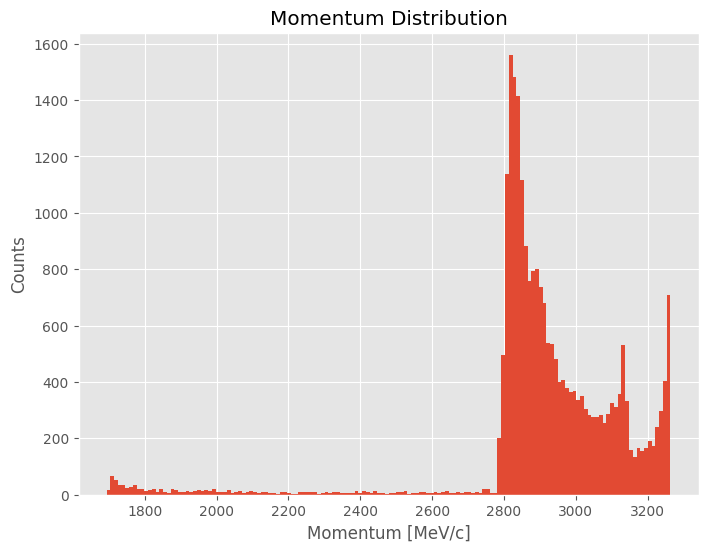

In [ ]:
plt.figure(figsize=(8,6))

plt.hist(
    p_best,
    bins=150
)

plt.xlabel('Momentum [MeV/c]')
plt.ylabel('Counts')

plt.title('Momentum Distribution')

plt.grid(True)

plt.show()

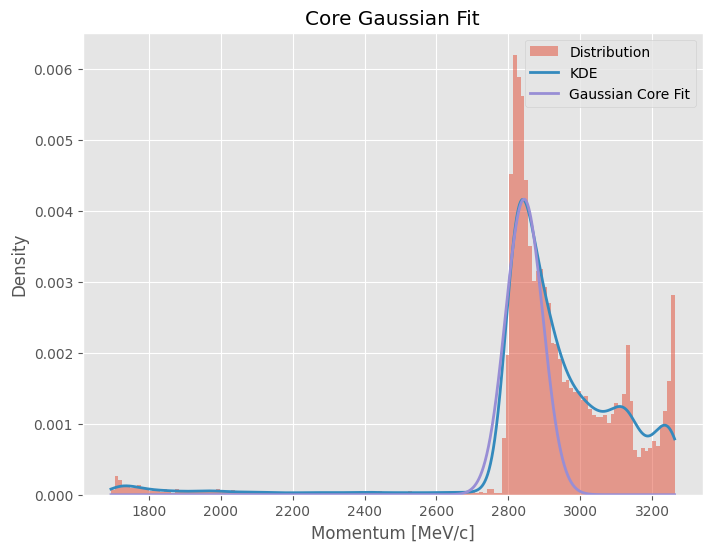

Core mean = 2844.0629 MeV/c
Core sigma = -52.0666 MeV/c


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma):

    return A*np.exp(
        -(x-mu)**2/(2*sigma**2)
    )

p = p_best.copy()

kde = gaussian_kde(p)

x = np.linspace(
    np.min(p),
    np.max(p),
    2000
)

y = kde(x)

peak_index = np.argmax(y)

peak_x = x[peak_index]

fit_width = 40

fit_mask = (
    (x > peak_x-fit_width)
    &
    (x < peak_x+fit_width)
)

x_fit = x[fit_mask]
y_fit = y[fit_mask]

A0 = np.max(y_fit)
mu0 = peak_x
sigma0 = np.std(p)

popt, _ = curve_fit(
    gaussian,
    x_fit,
    y_fit,
    p0=[A0, mu0, sigma0]
)

A_fit, mu_fit, sigma_fit = popt

gauss_fit = gaussian(
    x,
    A_fit,
    mu_fit,
    sigma_fit
)

plt.figure(figsize=(8,6))

plt.hist(
    p,
    bins=150,
    density=True,
    alpha=0.5,
    label='Distribution'
)

plt.plot(
    x,
    y,
    linewidth=2,
    label='KDE'
)

plt.plot(
    x,
    gauss_fit,
    linewidth=2,
    label='Gaussian Core Fit'
)

plt.xlabel('Momentum [MeV/c]')
plt.ylabel('Density')

plt.title('Core Gaussian Fit')

plt.legend()
plt.grid(True)

plt.show()

print(f"Core mean = {mu_fit:.4f} MeV/c")
print(f"Core sigma = {sigma_fit:.4f} MeV/c")

In [ ]:
import numpy as np
from scipy.optimize import minimize

def match_momentum_spread(df, initial_guess=[0.32, -0.05, 0.27]):
    """
    Optimizes R56, Vdeb, and Phasdeb to minimize the total RMS momentum spread.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The beam dataframe containing 't[mm/c]' and 'p[MeV/c]'.
    initial_guess : list
        Starting values for [R56, Vdeb, Phasdeb].
    """
    # Constant settings matching your notebook
    c = 299792458
    freq = 3e9
    k = 2 * np.pi * freq / c

    # Initial coordinates and reference energy
    z_i = df['t[mm/c]'].values * 1e-3
    p_i = df['p[MeV/c]'].values
    Eref = np.mean(p_i)
    delta_i = p_i / Eref - 1

    # Objective function to minimize
    def objective_function(params):
        R56, Vdeb, Phasdeb = params
        
        # Apply compressor and RF kick equations from your notebook
        z_f = z_i + R56 * delta_i
        delta_f = delta_i + Vdeb * np.sin(k * z_f + Phasdeb)
        p_f = Eref * (1 + delta_f)
        
        # Calculate full relative RMS momentum spread (%)
        rms_spread = (np.std(p_f) / np.mean(p_f)) * 100
        
        # Optional: If you want to minimize a 90% core spread like in your Cell 18, 
        # uncomment the lines below:
        # lower_p = np.percentile(p_f, 5)
        # upper_p = np.percentile(p_f, 95)
        # core_mask = (p_f >= lower_p) & (p_f <= upper_p)
        # rms_spread = (np.std(p_f[core_mask]) / np.mean(p_f[core_mask])) * 100
        
        return rms_spread

    print("Running Simplex optimization...")
    res = minimize(
        objective_function, 
        initial_guess, 
        method='Nelder-Mead',
        options={'xatol': 1e-5, 'fatol': 1e-6}
    )
    
    if res.success:
        print("\n--- Optimization Successful ---")
        print(f"Best R56:     {res.x[0]:.5f} m")
        print(f"Best Vdeb:    {res.x[1]:.5f}")
        print(f"Best Phasdeb: {res.x[2]:.5f} rad")
        print(f"Minimum RMS Momentum Spread: {res.fun:.3f}%")
        return res.x
    else:
        print("Optimization failed to converge perfectly:", res.message)
        return res.x
    
# 1. Run the optimization function on your beam data
best_params = match_momentum_spread(df, initial_guess=[0.32, -0.05, 0.27])

# 2. Extract the optimized parameters
best_R56, best_Vdeb, best_Phasdeb = best_params

# 3. Apply the optimized parameters to generate the final distribution for plotting
c = 299792458
freq = 3e9
k = 2 * np.pi * freq / c

df_optimized = df.copy()
Eref = np.mean(df_optimized['p[MeV/c]'])
delta_i = df_optimized['p[MeV/c]'] / Eref - 1
z_i = df_optimized['t[mm/c]'] * 1e-3

# Final transformations
z_f = z_i + best_R56 * delta_i
delta_f = delta_i + best_Vdeb * np.sin(k * z_f + best_Phasdeb)

df_optimized['t[mm/c]'] = z_f
df_optimized['p[MeV/c]'] = Eref * (1 + delta_f)

print("df_optimized dataframe is now ready for phase-space visualization!")

Running Simplex optimization...

--- Optimization Successful ---
Best R56:     0.44716 m
Best Vdeb:    -0.06756
Best Phasdeb: 1.09452 rad
Minimum RMS Momentum Spread: 5.223%
df_optimized dataframe is now ready for phase-space visualization!


In [ ]:
import numpy as np
import pandas as pd
import xpart as xp

def evaluate_ecs_performance(params, df_raw, ring, ring_tw, p0c_ref, n_particles=500, num_turns=100, seed=74):
    """
    Evaluates a single combination of ECS parameters for both 
    RMS momentum spread and tracking survival efficiency.
    """
    R56, Vdeb, Phasdeb = params
    
    c = 299792458
    freq = 3e9
    k = 2 * np.pi * freq / c
    fixed_e_mev = p0c_ref / 1e6

    # Sample a subset for fast tracking (consistent with Cell 16)
    df_subset = df_raw.sample(n=n_particles, random_state=seed)
    
    # 1. Apply the ECS equations to the initial uncompressed coordinates
    z_i = df_subset['t[mm/c]'].values * 1e-3  # meters
    p_i = df_subset['p[MeV/c]'].values        # MeV/c
    Eref = np.mean(p_i)
    delta_i = p_i / Eref - 1

    z_f = z_i + R56 * delta_i
    delta_f = delta_i + Vdeb * np.sin(k * z_f + Phasdeb)
    p_f = Eref * (1 + delta_f)

    # Calculate relative RMS momentum spread (%)
    rms_spread = (np.std(p_i) / np.mean(p_i)) * 100

    # 2. Map coordinates to Xtrack Particles with dispersion matching
    x_in = df_subset['x[mm]'].values / 1000.0
    px_in = df_subset['xp[mrad]'].values / 1000.0
    y_in = df_subset['y[mm]'].values / 1000.0
    py_in = df_subset['yp[mrad]'].values / 1000.0
    
    delta_in = (p_f - fixed_e_mev) / fixed_e_mev
    zeta_in = z_f  

    x_matched = x_in + ring_tw.dx[0] * delta_in
    px_matched = px_in + ring_tw.dpx[0] * delta_in
    y_matched = y_in + ring_tw.dy[0] * delta_in
    py_matched = py_in + ring_tw.dpy[0] * delta_in

    p_test = xp.Particles(
        p0c=p0c_ref,
        mass0=xp.ELECTRON_MASS_EV,
        x=x_matched, px=px_matched,
        y=y_matched, py=py_matched,
        delta=delta_in,
        zeta=zeta_in
    )

    # 3. Track through the ring to measure injection efficiency
    ring.track(p_test, num_turns=num_turns)
    survived = np.sum(p_test.state > 0)
    efficiency = (survived / n_particles) * 100

    return rms_spread, efficiency


def run_multi_objective_scan(df_raw, ring, ring_tw, p0c_ref, n_samples=150):
    """
    Performs a randomized parameter search to find the optimal trade-off space.
    """
    np.random.seed(42)
    
    # Define search bounds centered around your current best region
    R56_samples = np.random.uniform(0.20, 0.45, n_samples)
    Vdeb_samples = np.random.uniform(-0.15, 0.0, n_samples)
    Phasdeb_samples = np.random.uniform(0.10, 0.45, n_samples)
    
    scan_results = []
    
    print(f"Starting joint scan over {n_samples} configurations...")
    for i in range(n_samples):
        R56 = R56_samples[i]
        Vdeb = Vdeb_samples[i]
        Phasdeb = Phasdeb_samples[i]
        
        spread, eff = evaluate_ecs_performance(
            [R56, Vdeb, Phasdeb], df_raw, ring, ring_tw, p0c_ref
        )
        
        scan_results.append({
            'R56': R56,
            'Vdeb': Vdeb,
            'Phasdeb': Phasdeb,
            'RMS_Spread_%': spread,
            'Efficiency_%': eff
        })
        
        if (i + 1) % 15 == 0:
            print(f"Progress: {i + 1}/{n_samples} configurations evaluated.")
            
    df_res = pd.DataFrame(scan_results)
    
    # Sort first by highest injection efficiency, then by lowest momentum spread
    df_res = df_res.sort_values(by=['Efficiency_%', 'RMS_Spread_%'], ascending=[False, True])
    return df_res

# Run the scan
scan_df = run_multi_objective_scan(df, ring, ring_tw, p0c_reference, n_samples=150)

# Display the top 10 best configurations
print("\nTop 10 configurations (Highest Efficiency + Lowest Spread):")
display(scan_df.head(10))

Starting joint scan over 150 configurations...
Progress: 15/150 configurations evaluated.
Progress: 30/150 configurations evaluated.
Progress: 45/150 configurations evaluated.
Progress: 60/150 configurations evaluated.
Progress: 75/150 configurations evaluated.
Progress: 90/150 configurations evaluated.
Progress: 105/150 configurations evaluated.
Progress: 120/150 configurations evaluated.
Progress: 135/150 configurations evaluated.
Progress: 150/150 configurations evaluated.

Top 10 configurations (Highest Efficiency + Lowest Spread):


,R56,Vdeb,Phasdeb,RMS_Spread_%,Efficiency_%
20,0.352963,-0.048365,0.292229,7.599698,86.0
115,0.417865,-0.038885,0.256956,7.599698,85.2
62,0.407184,-0.052206,0.260389,7.599698,84.4
116,0.400918,-0.045448,0.202624,7.599698,83.6
9,0.377018,-0.040768,0.194791,7.599698,83.0
43,0.427330,-0.055035,0.251848,7.599698,82.2
11,0.442477,-0.055154,0.127460,7.599698,80.6
50,0.442396,-0.053695,0.276098,7.599698,80.6
70,0.393061,-0.051358,0.135272,7.599698,79.8
35,0.402099,-0.051002,0.114255,7.599698,79.4


In [ ]:
def evaluate_ecs_and_energy_performance(params, df_raw, ring, ring_tw, p0c_ref_base, n_particles=500, num_turns=100, seed=74):
    """
    Evaluates a combination of ECS parameters AND an operational energy shift
    for both RMS momentum spread and tracking survival efficiency.
    """
    R56, Vdeb, Phasdeb, E_scale = params
    
    # 1. Scale the ring's operational reference energy for this configuration
    p0c_ref = p0c_ref_base * (1.0 + E_scale)
    fixed_e_mev = p0c_ref / 1e6
    
    c = 299792458
    freq = 3e9
    k = 2 * np.pi * freq / c

    # Sample a subset for fast tracking
    df_subset = df_raw.sample(n=n_particles, random_state=seed)
    
    # 2. Apply the ECS equations to the initial uncompressed coordinates
    z_i = df_subset['t[mm/c]'].values * 1e-3  # meters
    p_i = df_subset['p[MeV/c]'].values        # MeV/c
    Eref = np.mean(p_i)
    delta_i = p_i / Eref - 1

    z_f = z_i + R56 * delta_i
    delta_f = delta_i + Vdeb * np.sin(k * z_f + Phasdeb)
    p_f = Eref * (1 + delta_f)

    # Calculate relative RMS momentum spread (%) of the compressed beam
    rms_spread = (np.std(p_i) / np.mean(p_i)) * 100

    # 3. Map coordinates to Xtrack Particles with dispersion matching
    x_in = df_subset['x[mm]'].values / 1000.0
    px_in = df_subset['xp[mrad]'].values / 1000.0
    y_in = df_subset['y[mm]'].values / 1000.0
    py_in = df_subset['yp[mrad]'].values / 1000.0
    
    # delta_in is now calculated relative to the scanned operational energy
    delta_in = (p_f - fixed_e_mev) / fixed_e_mev
    zeta_in = z_f  

    x_matched = x_in + ring_tw.dx[0] * delta_in
    px_matched = px_in + ring_tw.dpx[0] * delta_in
    y_matched = y_in + ring_tw.dy[0] * delta_in
    py_matched = py_in + ring_tw.dpy[0] * delta_in

    p_test = xp.Particles(
        p0c=p0c_ref,
        mass0=xp.ELECTRON_MASS_EV,
        x=x_matched, px=px_matched,
        y=y_matched, py=py_matched,
        delta=delta_in,
        zeta=zeta_in
    )

    # 4. Track through the ring to measure injection efficiency
    ring.track(p_test, num_turns=num_turns)
    survived = np.sum(p_test.state > 0)
    efficiency = (survived / n_particles) * 100

    return rms_spread, efficiency

def run_4d_operational_scan(df_raw, ring, ring_tw, p0c_ref_base, n_samples=200):
    """
    Performs a 4D randomized parameter search including operational energy tuning.
    """
    np.random.seed(42)
    
    # Define search bounds for the 4 parameters
    R56_samples = np.random.uniform(0.20, 0.45, n_samples)
    Vdeb_samples = np.random.uniform(-0.15, 0.0, n_samples)
    Phasdeb_samples = np.random.uniform(0.10, 0.45, n_samples)
    
    # Scan relative energy offset from -0.5% to +0.5%
    E_scale_samples = np.random.uniform(-0.005, 0.005, n_samples) 
    
    scan_results = []
    
    print(f"Starting 4D joint scan over {n_samples} configurations...")
    for i in range(n_samples):
        R56 = R56_samples[i]
        Vdeb = Vdeb_samples[i]
        Phasdeb = Phasdeb_samples[i]
        E_scale = E_scale_samples[i]
        
        spread, eff = evaluate_ecs_and_energy_performance(
            [R56, Vdeb, Phasdeb, E_scale], df_raw, ring, ring_tw, p0c_ref_base
        )
        
        # Calculate the resulting physical energy in GeV for easy reading
        scanned_energy_gev = (p0c_ref_base * (1.0 + E_scale)) / 1e9
        
        scan_results.append({
            'R56': R56,
            'Vdeb': Vdeb,
            'Phasdeb': Phasdeb,
            'E_offset_%': E_scale * 100,
            'Operational_E_GeV': scanned_energy_gev,
            'RMS_Spread_%': spread,
            'Efficiency_%': eff
        })
        
        if (i + 1) % 20 == 0:
            print(f"Progress: {i + 1}/{n_samples} configurations evaluated.")
            
    df_res = pd.DataFrame(scan_results)
    
    # Sort by highest efficiency first, then lowest momentum spread
    df_res = df_res.sort_values(by=['Efficiency_%', 'RMS_Spread_%'], ascending=[False, True])
    return df_res

# Execute the 4D parameter scan
scan_4d_df = run_4d_operational_scan(df, ring, ring_tw, p0c_reference, n_samples=200)

# Display the top 10 best matched configurations
display(scan_4d_df.head(10))

Starting 4D joint scan over 200 configurations...
Progress: 20/200 configurations evaluated.
Progress: 40/200 configurations evaluated.
Progress: 60/200 configurations evaluated.
Progress: 80/200 configurations evaluated.
Progress: 100/200 configurations evaluated.
Progress: 120/200 configurations evaluated.


KeyboardInterrupt: 

In [ ]:
display(scan_4d_df.head(10))

NameError: name 'scan_4d_df' is not defined